In [22]:
import pandas as pd

In [ ]:
df_customers_real = pd.read_csv("data/olist_customers_dataset.csv")
df_geolocation_real = pd.read_csv("data/olist_geolocation_dataset.csv")
df_order_items_real = pd.read_csv("data/olist_order_items_dataset.csv")
df_order_payments_real = pd.read_csv("data/olist_order_payments_dataset.csv")
df_order_reviews_real = pd.read_csv("data/olist_order_reviews_dataset.csv")
df_orders_real = pd.read_csv("data/olist_orders_dataset.csv")
df_products_real = pd.read_csv("data/olist_products_dataset.csv")
df_sellers_real = pd.read_csv("data/olist_sellers_dataset.csv")
df_translation_real = pd.read_csv("data/product_category_name_translation.csv")

In [ ]:
df_customers = df_customers_real.copy()
df_geolocation = df_geolocation_real.copy()
df_order_items = df_order_items_real.copy()
df_order_payments = df_order_payments_real.copy()
df_order_reviews = df_order_reviews_real.copy()
df_orders = df_orders_real.copy()
df_products = df_products_real.copy()
df_sellers = df_sellers_real.copy()
df_translation = df_translation_real.copy()

In [ ]:
df_order_payments.shape

(103886, 5)

In [ ]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
df_order_payments.value_counts('payment_sequential')

payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
17        6
19        6
16        6
18        6
21        4
20        4
22        3
25        2
26        2
24        2
23        2
27        1
29        1
28        1
Name: count, dtype: int64

In [ ]:
# sequential이 최대인 주문 찾기
max_order_id = (
    df_order_payments.groupby('order_id')['payment_sequential']
    .max()
    .idxmax()  # sequential 최댓값을 가진 order_id
)

# 그 주문의 전체 결제 내역 출력
result = df_order_payments[df_order_payments['order_id'] == max_order_id].sort_values('payment_sequential')
print(result[['payment_sequential', 'payment_type', 'payment_installments', 'payment_value']])
print(f"\n총 결제 금액: {result['payment_value'].sum():.2f}")

        payment_sequential payment_type  payment_installments  payment_value
14321                    1      voucher                     1           3.71
23074                    2      voucher                     1           8.51
65641                    3      voucher                     1           2.95
9985                     4      voucher                     1          29.16
28330                    5      voucher                     1           0.66
29648                    6      voucher                     1           5.02
82593                    7      voucher                     1           0.32
68853                    8      voucher                     1          26.02
17274                    9      voucher                     1           1.08
19565                   10      voucher                     1          12.86
32519                   11      voucher                     1           4.03
73537                   12      voucher                     1           3.60

In [ ]:
# ── 기본 확인 ──
print(f"전체 행수: {len(df_order_payments):,}")
print(f"\n결측값:\n{df_order_payments.isnull().sum()}")
print(f"\npaymant_type 분포:\n{df_order_payments['payment_type'].value_counts()}")
#print(f"\npayment_sequential 분포:\n{order_payments['payment_sequential'].value_counts().sort_index()}")

전체 행수: 103,886

결측값:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

paymant_type 분포:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


order_payments는 1개 주문 = 여러 행이 될 수 있는 테이블

(한 주문에 여러 결제 수단을 섞어 쓰는 것이 가능 예) 바우처 30% + 신용카드 70%)

In [ ]:
# 'not_defined'는 의미 없는 값이므로 제거
df_order_payments = df_order_payments[df_order_payments['payment_type'] != 'not_defined']

In [ ]:
df_order_payments.shape

(103883, 5)

In [ ]:
df_order_payments.value_counts('payment_sequential')

payment_sequential
1     99357
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
17        6
19        6
16        6
18        6
21        4
20        4
22        3
25        2
26        2
24        2
23        2
27        1
29        1
28        1
Name: count, dtype: int64

In [ ]:
# ── 3. 주문별 집계 ──
payments_agg = df_order_payments.groupby('order_id').agg(
    # 주결제 수단 (sequential=1)
    main_payment_type   = ('payment_type', 'first'),
    # 최대 할부 개월수
    max_installments    = ('payment_installments', 'max'),
    # 총 결제 금액
    total_payment_value = ('payment_value', 'sum'),
    # 결제 수단 개수 (쿠폰 많이 쓸수록 높아짐)
    payment_count       = ('payment_sequential', 'max'),
    # 바우처 포함 여부 (보조 수단으로 쓰이는 경우가 많아서 별도 체크)
    has_voucher         = ('payment_type', lambda x: int('voucher' in x.values)),
).reset_index()
# ── 4. 주결제 수단 One-Hot 인코딩 ──
# → pay_credit_card, pay_boleto, pay_voucher, pay_debit_card 컬럼 자동 생성
payments_agg = pd.get_dummies(payments_agg, columns=['main_payment_type'], prefix='pay')
print(f"집계 후 행수: {len(payments_agg):,}")
print(payments_agg.head())
print(payments_agg.columns.tolist())


집계 후 행수: 99,437
                           order_id  max_installments  total_payment_value  \
0  00010242fe8c5a6d1ba2dd792cb16214                 2                72.19   
1  00018f77f2f0320c557190d7a144bdd3                 3               259.83   
2  000229ec398224ef6ca0657da4fc703e                 5               216.87   
3  00024acbcdf0a6daa1e931b038114c75                 2                25.78   
4  00042b26cf59d7ce69dfabb4e55b4fd9                 3               218.04   

   payment_count  has_voucher  pay_boleto  pay_credit_card  pay_debit_card  \
0              1            0       False             True           False   
1              1            0       False             True           False   
2              1            0       False             True           False   
3              1            0       False             True           False   
4              1            0       False             True           False   

   pay_voucher  
0        False  
1        Fal

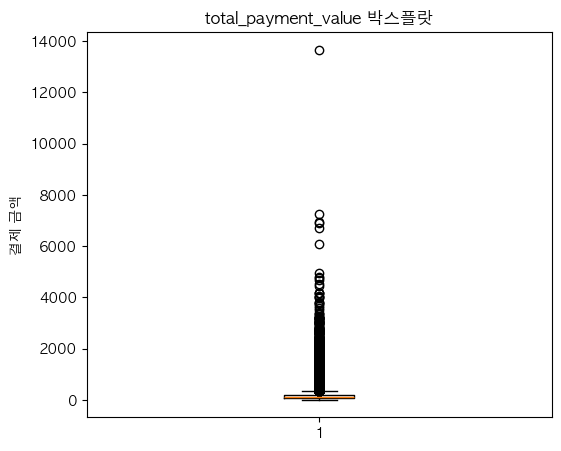

In [32]:
plt.figure(figsize=(6, 5))
plt.boxplot(payments_agg['total_payment_value'])
plt.title('total_payment_value 박스플랏')
plt.ylabel('결제 금액')
plt.show()

In [33]:
Q1 = payments_agg['total_payment_value'].quantile(0.25)
Q3 = payments_agg['total_payment_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = payments_agg[
    (payments_agg['total_payment_value'] < lower) |
    (payments_agg['total_payment_value'] > upper)
]

print(f"Q1: {Q1:.2f} / Q3: {Q3:.2f} / IQR: {IQR:.2f}")
print(f"이상치 기준: {lower:.2f} ~ {upper:.2f}")
print(f"이상치 수: {len(outliers):,}건 ({len(outliers)/len(payments_agg)*100:.1f}%)")
print(f"\n이상치 최댓값 TOP 5:")
print(outliers['total_payment_value'].nlargest(5).values)

Q1: 62.01 / Q3: 176.97 / IQR: 114.96
이상치 기준: -110.43 ~ 349.41
이상치 수: 7,866건 (7.9%)

이상치 최댓값 TOP 5:
[13664.08  7274.88  6929.31  6922.21  6726.66]


In [37]:
print(payments_agg['total_payment_value'].min())
print(payments_agg['total_payment_value'].max())

9.59
13664.08


2300원~ 328만원으로 모두 가능한 범위

이상치 X 판단

최종 df: payments_agg

In [50]:
payments_agg.head()

,order_id,max_installments,total_payment_value,payment_count,has_voucher,pay_boleto,pay_credit_card,pay_debit_card,pay_voucher
0,00010242fe8c5a6d1ba2dd792cb16214,2,72.19,1,0,False,True,False,False
1,00018f77f2f0320c557190d7a144bdd3,3,259.83,1,0,False,True,False,False
2,000229ec398224ef6ca0657da4fc703e,5,216.87,1,0,False,True,False,False
3,00024acbcdf0a6daa1e931b038114c75,2,25.78,1,0,False,True,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,3,218.04,1,0,False,True,False,False
